# AA_Cam_pose_sweeps

Sweeps camera density (target frame count, `cam_poses`) at a fixed video range (`start_3D_recon`..`end_3D_recon`) through every reconstruction technique, scores each against GPS ground truth, and pools everything into one CSV.

Process code (scoring, resumability/status tracking, disk-retention cleanup, the sweep loop itself) lives in `AA_cam_pose_sweeps.py`, next to this notebook -- import it, don't copy it, so fixes/improvements there apply to every per-case copy of this notebook automatically. This notebook only holds what varies per case:
- **Config**: `case_name`, frame range, `CAM_POSES`, `TECHNIQUE_ORDER`, `FLAGS`, and `DATA_STORAGE` (what to keep on disk afterwards vs delete).
- **Part 2 (Sweep)** is expensive (minutes per technique per density) and resumable -- safe to interrupt/kill and re-run from the top. GPU OOM kills the whole kernel outright (not a catchable Python exception), so the resumability design is disk-based, not in-process -- see `AA_cam_pose_sweeps.py`'s Resumability infrastructure section.
- **Part 3 (Load + plot)** is cheap -- it only reads the pooled CSV off disk, so the chart can be restyled/re-run any number of times without re-touching the sweep. Stays notebook-side since it's meant to be freely tweaked per case.

`align_and_score` and the trace loaders are reused from `F_post_recon_processing.py`/`AA_cam_pose_sweeps.py`, same functions `AA_Cam_pose_estimate_batches.ipynb` uses.

In [1]:
%load_ext autoreload
%autoreload 2

## Config

In [2]:
import sys
from pathlib import Path

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)

from A_Config import set_case, case_dir
from Two2D.B_video_processing import video_fps
from templates.AA_cam_pose_sweeps import reset_sweep_state, run_density_sweep

case_name = "401_Hide_n_seek"
experiment = "Cam_pose_v01"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir   = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]


# Fixed video range -- only the frame DENSITY within this range varies across the sweep.
# Hardcoded per AI_coppertest3_vggt.ipynb's precedent (no reusable start/end-frame config exists yet).
start_3D_recon = 975
end_3D_recon = 7595


fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")

# Target frame counts to sweep, ascending -- ascending order matters for the
# OOM-precaution logic in run_density_sweep (more frames -> more GPU memory).
CAM_POSES = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,275,300]

# Fixed run order (user-specified) -- cheapest/most-reliable techniques first.
TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

# Which techniques are actually enabled -- same defaults as AA_Cam_pose_estimate_batches.ipynb.
FLAGS = {
    "CUT3R":       True,
    "CUT3R_Revisit": True,
    "lingbot-map": True,
    "VGGT-Omega":  True,
    "MegaSaM":     True,
    "VGGT":        True,
}

# What the sweep keeps on disk afterwards vs deletes -- see AA_cam_pose_sweeps.py's
# _cleanup_technique_output for exactly what each toggle controls.
DATA_STORAGE = {
    "keep_inputs":     True,  # extracted frames per density (020_frames_for_cam_poses)
    "keep_recon_data": True,  # full heavy technique output (images/depth/point-clouds/caches)
    "keep_cam_poses":  True,   # lightweight <technique_output>/CAM_poses/poses.csv per density
    "full_pose":       True,  # rotation too, not just translation, in the retained CSV
    "render_bev":      True,   # one <technique_output>/BEV/bev.png per technique/density --
                                # every technique gets a Reconstruction (natively for VGGT-Omega,
                                # via F_transpose_to_recon_objects.py adapters for the rest), then
                                # P_projection_mapping.BEV_tile_render_PM renders from it. Cheap
                                # to keep even when keep_recon_data=False.
}
out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

project_root: /workspace/project


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


video fps: 30.000


## Reset sweep state

Deletes **only** this sweep's own output -- everything from running this sweep, nothing more, nothing less: every `poses_*` frame/reconstruction folder under the `experiment` tag defined above, plus the status/results CSVs. Nothing from `AA_Cam_pose_estimate_batches.ipynb` (different experiment name) or anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would* delete. Flip it to `True` and re-run the cell to actually delete.

In [ ]:
CONFIRM_DELETE = False  # flip to True and re-run this cell to actually delete

reset_sweep_state(case_name, experiment, confirm=CONFIRM_DELETE)

In [ ]:
(end_3D_recon - start_3D_recon)

## Ground truth

Same manual GT loading as `AA_Cam_pose_estimate_batches.ipynb` -- see that notebook for the naming-convention caveat.

In [3]:
from Q_GPS_processing import csv_to_GPS_dict

gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

39 GT anchors loaded from GPS_tags.csv


## Part 2 -- Sweep (expensive, resumable, run once/rarely)

`run_density_sweep` (in `AA_cam_pose_sweeps.py`) gives each `cam_poses` value its own frames/output folders via a nested experiment tag (`f"{experiment}/poses_{cam_poses:04d}"` passed to `set_case`) -- this makes every `A_Config` getter (including `run_lingbot_map`'s, which has no path parameters at all and only reads the zero-arg getters) automatically density-scoped, with no per-function path-wrangling needed.

Safe to interrupt/kill and re-run from the top at any point.

In [4]:
run_density_sweep(
    case_name, experiment, video_path, start_3D_recon, end_3D_recon,
    CAM_POSES, TECHNIQUE_ORDER, FLAGS, DATA_STORAGE, project_root, GPS_dict,
)

Video   : VID_20260815_165930783.mp4
          30 fps · 7655 frames · 255.4s
Range   : frames 975-7595 (6620 frames)
Sampling: every 265 frames (8.833333333333334s) → 25 candidates
Window  : ±7 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 6620/6620 [00:24<00:00, 267.96fr/s]


Selected: 25 frames  (12 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 6620/6620 [00:10<00:00, 609.06fr/s]


Log     : /workspace/project/Data/401_Hide_n_seek/020_frames_for_cam_poses/Cam_pose_v01/poses_0025/selection_log.json
Sharpness (at 25% res): min 277 · mean 4016 · max 10259
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Loading model...
... loading model from /workspace/project/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
25 frames  →  /workspace/project/Data/401_Hide_n_seek/035_CUT3R_output/Cam_pose_v01/poses_0025


...

################################
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
median_hessian, median_calib  tensor(1977.1953, device='cuda:0') tensor([2.3663e+19], device='cuda:0')
_opt_intr  True  use_mono  False  alpha  0.0
################## KEYFRAME BUNDLE ADJUSTMENT ################################  use_mono  False
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
Global BA Iteration #11
Global BA Iteration #12
Global BA Iteration #13
Global BA Iteration #14
Global BA Iteration #15
Global BA Iteration #16
Global BA Iteration #17
Global BA Iteration #18
Global BA Iteration #19
Global BA Iteration #20

GLOBAL FRAME BA ####

288it [00:08, 33.53it/s]
  0%|          | 0/287 [00:00<?, ?it/s]/workspace/project/.conda_envs/mega_sam/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995026/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 273/273 [00:22<00:00, 12.02it/s]


  RAFT flow done in 144s
$ conda run --no-capture-output -n mega_sam python cvd_opt/cvd_opt.py --scene_name 401_Hide_n_seek --w_grad 2.0 --w_normal 5.0
CVD optimisation: 401_Hide_n_seek
step  0 1.2211017608642578
step  20 0.7944825291633606
step  40 0.5869855284690857
step  60 0.5307570099830627
step  80 0.5133780837059021
step  0 0.4838807284832001
step  20 0.5074727535247803
step  40 0.46900177001953125
step  60 0.45042791962623596
step  80 0.4372338056564331
step  100 0.4258691966533661
step  120 0.416085422039032
step  140 0.4072519838809967
step  160 0.39903292059898376
step  180 0.3916685879230499
step  200 0.38492220640182495
step  220 0.378831684589386
step  240 0.37342745065689087
step  260 0.3683980107307434
step  280 0.36379507184028625
step  300 0.35972467064857483
step  320 0.35604557394981384
step  340 0.3525524139404297
step  360 0.3493182361125946
step  380 0.3464793264865875


/workspace/project/Models/mega-sam/cvd_opt/cvd_opt.py:456: RuntimeWarning: overflow encountered in cast
  depths=np.clip(np.float16(1.0 / disp_data_opt), 1e-3, 1e2),


  CVD optimisation done in 298s
Output: /workspace/project/Data/401_Hide_n_seek/036_MEGASAM_output/Cam_pose_v01/poses_0300/401_Hide_n_seek_sgd_cvd_hr.npz
min depth tensor(0.0010, device='cuda:0')
torch.Size([55166976, 3])
mins, maxes and ranges -20.87899088859558 135.01427245140076 155.89326333999634 -91.13431549072266 87.40369415283203 178.5380096435547
scale - original 44.52055510308838
GPS anchor at frame 37 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 217 dropped: out of range or lost to a closer anchor.
GPS anchor at frame 638 dropped: out of range or lost to a closer anchor.
A,B 36 36
[MegaSaM @ 300] success, rmse=8.406
[VGGT @ 300] already failed (skipped_precautionary), skipping


## Part 3 -- Load + plot (cheap, re-runnable independently)

Reads `density_sweep_results.csv` fresh from disk -- does not depend on Part 2 having just run, so this cell can be re-run/restyled any number of times without touching the sweep. Colour mapping matches the informal `tab10`-by-insertion-order precedent in `AA_CAM_POSE_COMPARE_01.ipynb` cell 25 (`lingbot_map`, `VGGT_O`, `CUT3R`, `MegaSaM` kept at their original slots; `VGGT` plain wasn't in that precedent, so it reuses the freed `Reality_Scan` slot).

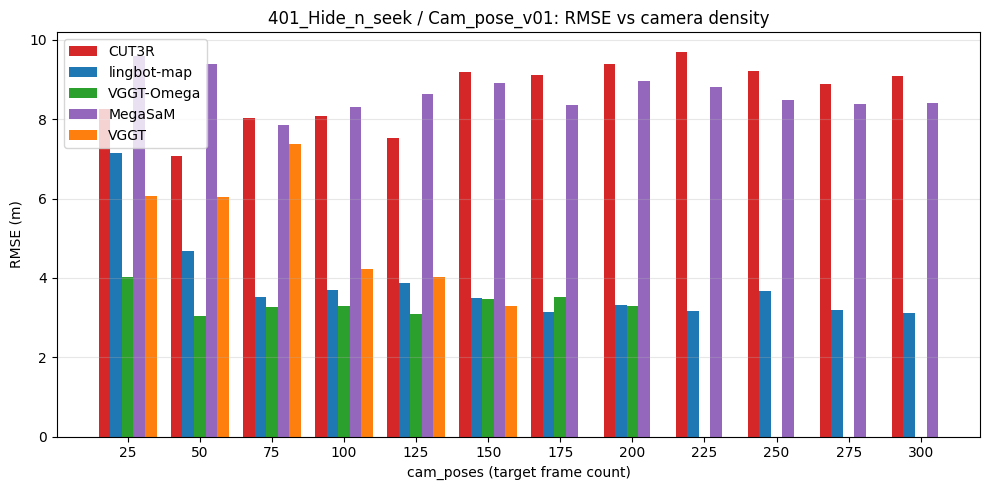

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir


results_path = case_dir() / "080_Experiments" / f"{experiment}" /f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],  # no precedent either -- n
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE.svg", format="svg", bbox_inches="tight")

KeyError: 'cam_poses'

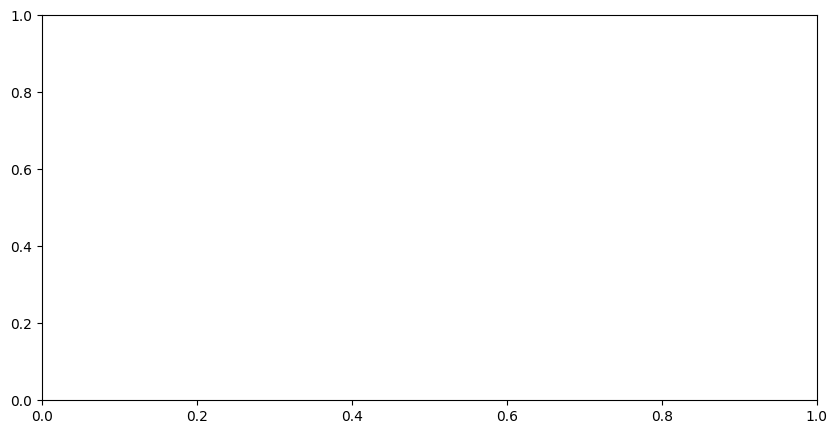

In [4]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir



set_case(case_name, experiment)
results_path = case_dir() / "080_Experiments" / f"{experiment}" / f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    #ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))
    ax.plot(sub["cam_poses"], sub["rmse"], marker="o", markersize=3, label=technique, color=COLOR_MAP.get(technique))
ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE_nocut3rr.svg", format="svg", bbox_inches="tight")

'''
fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.plot(sub["cam_poses"], sub["rmse"], marker="o", markersize=3, label=technique, color=COLOR_MAP.get(technique))
ax.set_xlabel("cam_poses, (N=3)")
ax.set_ylabel("RMSE (m)")
ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "pooled_RMSE_no stdev_vggt0_vs_ling.pdf", format="pdf", bbox_inches="tight")'''

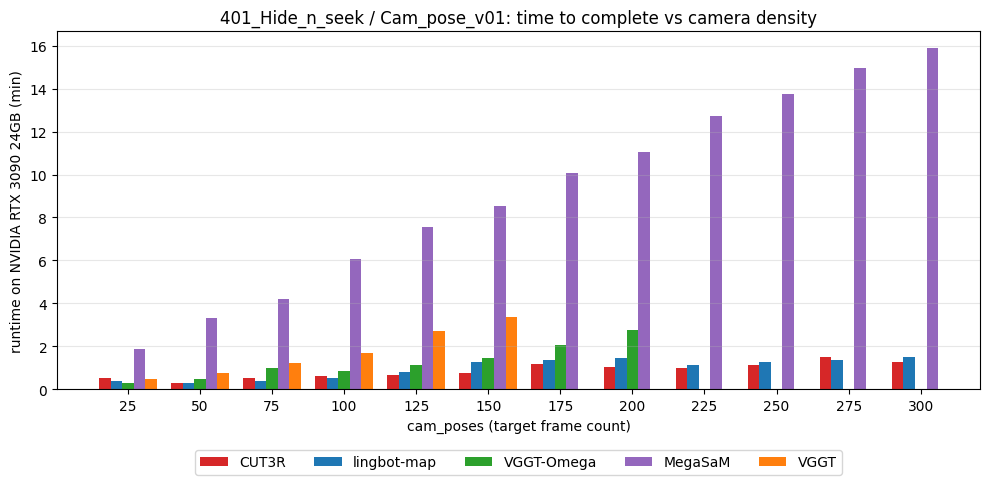

In [6]:
fig3, ax3 = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["runtime (min)"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax3.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax3.set_xticks(x)
ax3.set_xticklabels(cam_poses_vals)
ax3.set_xlabel("cam_poses (target frame count)")
ax3.set_ylabel("runtime on NVIDIA RTX 3090 24GB (min)")
ax3.set_title(f"{case_name} / {experiment}: time to complete vs camera density")
ax3.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax3.grid(axis="y", alpha=0.3)
fig3.tight_layout()
fig3.savefig(out_dir / f"{case_name}_{experiment}_runtime.svg", format="svg", bbox_inches="tight")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

runs = [
    ("07_Tropea_cafe", "100m_gps_v3"),
    ("01_walk", "sweep_inferity"),
    ("01_walk", "sweeps_short_inferity"),
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "cam_poses"], as_index=False)[["rmse", "mean dist"]].mean()

TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.plot(sub["cam_poses"], sub["rmse"], marker="o", markersize=3, label=technique, color=COLOR_MAP.get(technique))



ax.set_xlabel("cam_poses, (N=3)")
ax.set_ylabel("RMSE (m)")
ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "pooled_RMSE_no stdev_vggt0_vs_ling.pdf", format="pdf", bbox_inches="tight")
